# Project Checkpoint 3 - Final Deliverable

Spring 2026 Data Science Project (CMSC320)

Members:

*Harshith Bachimanchi*

*Isaac Lee*

*Anjika Singh*

*Samuel McHugh*

*Logan Young*

[link to the drive containing all the important files](https://drive.google.com/drive/u/4/folders/1KfucHk9AYlI4f1MgPuHNJKWHT_5RumQL)

# Contributions:

***Samuel McHugh*** - Helped with deciding what parts of the data to look at(A). Did the testing about the different cities being symmetrical(C). Did the primary analysis with building and testing a model based on all factors looked at in the data analysis(D,E).

***Anjika Singh*** - Worked a little to decide what parts of the data to look at and what is necessary (B). Did the data visualization for the hypothesis testing of weekends versus weekdays and their influence on the number of visits (C). Did the plot visualization for the machine learning primary analysis (F).

***Isaac Lee*** - Worked on researching for data and shared with the team in the discussion phase(A). Explained the data set while also working on shrinking the size of our dataset (B) so the team can work on, and contributed towards visualizing the main hypothesis result (C).

***Logan Young*** - Worked on exploratory data analysis (C) and helped prepare and clean the data in the starting phase.

***Harshith Bachimanchi*** - Helped with the Visualization (C) and worked on the Final Project Tutorial Creation (G).

# Introduction:

The COVID-19 pandemic created disruptions on  how Americans interact with physical retail and restaurants. Policy for lockdowns, capacity restrictions paired with change in consumer preferences forced food and drink franchises to quickly change their operations while the long term effects on in person traffic remained as an open question. Understanding these shifts matters a lot for the practical decisions made by franchise managers, regional operators, and supply chain coordinators every week. These questions can be things like how many staff should be scheduled on a Friday evening, whether Sunday traffic should be expected to look more like 2019 or 2021, and whether some cities can recover from pandemics faster than others.This project looks into how the COVID-19 pandemic affected in person consumer traffic at food and drink franchises by analyzing weekly visit data using Wingstop locations across Maryland as our sample between 2018 and 2022.

The raw dataset includes many industries and the entire United States, but using it in full would interfere with the patterns we tried to identify. We narrowed our single restaurant brand within  a single state so that we can have external factors constant such as regional culture, menu, regulations. It also helps us to have a clear view of the effect of timing and location on consumer visits. Why Wingstop? Because our team loves Wingstop!

We will look into three questions which are: Does the day of the week meaningfully predict how busy a Wingstop location will be? How does the city of a location in Maryland influence visit patterns? And did the COVID-19 pandemic change customer foot traffic in a way that persists across cities and weekdays? We will not only look into these descriptively, but we will also be developing a forecasting model that combines these three factors to predict daily visit counts, that could be used by franchise managers in practice.


# Data Curation

To extract the useful information from the big dataset, we made an alternate file explicitly for data curation :

[link to the data curation](https://colab.research.google.com/drive/1vSxllnPSYJ6Gy4kzduj3GjguAvYirU5M?authuser=4)


The data we used was too big, so we trimmed it to just include Wingstop and Maryland.

Import data - wingstop - md.zip when running the code. The file can be found in the drive linked at the start.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

In [ ]:
df2018 = pd.read_csv("wingstop_md_2018.csv")
df2019 = pd.read_csv("wingstop_md_2019.csv")
df2020 = pd.read_csv("wingstop_md_2020.csv")
df2021 = pd.read_csv("wingstop_md_2021.csv")
df2022 = pd.read_csv("wingstop_md_2022.csv")

In [ ]:
df2018 = df2018.drop(columns=["safegraph_brand_ids"], errors = "ignore")
df2019 = df2019.drop(columns=["safegraph_brand_ids"], errors = "ignore")
df2020 = df2020.drop(columns=["safegraph_brand_ids"], errors = "ignore")
df2021 = df2021.drop(columns=["safegraph_brand_ids"], errors = "ignore")
df2022 = df2022.drop(columns=["safegraph_brand_ids"], errors = "ignore")

In [ ]:
df2018["Year"] = 2018
df2019["Year"] = 2019
df2020["Year"] = 2020
df2021["Year"] = 2021
df2022["Year"] = 2022

In [ ]:
df = pd.concat([df2018, df2019, df2020, df2021, df2022], ignore_index=True)

In [ ]:
# Do not run this cell multiple times before resetting.
import json
df = df.dropna()
days = ["Monday_Visits", "Tuesday_Visits", "Wednesday_Visits",
        "Thursday_Visits", "Friday_Visits", "Saturday_Visits", "Sunday_Visits"]
df["visits_by_day"] = df["visits_by_day"].apply(json.loads)
df[days] = pd.DataFrame(df["visits_by_day"].tolist(), index=df.index)

# 4. Exploratory Data Analysis
In this section, we explore the Wingstop Maryland dataset to uncover patterns in customer visit behavior across time, geography, and external events. Exploratory Data Analysis (EDA) serves two purposes: it builds our intuition about the data before modeling, and it justifies the features we ultimately chose for our machine learning model. Basically, we are getting a feel for the data before building useful analytics of it. Each of the three analyses below directly motivated a feature in our Random Forest regressor.

# 4.1 Does the Day of the Week Influence Visits?
Motivation: Before training any model, it is worth asking whether something as simple as the day of the week predicts how busy a Wingstop location will be. If visits are roughly uniform across the week, day of week would prove to not be a useful feature. If they are not, it tells us that customer behavior is structured around weekly fluctuations and that the day should be included as a predictor.
We examine both the mean and median visits per day across all Maryland Wingstop locations from 2018–2022. Using both statistics is intentional: the mean is sensitive to outliers like a special grand opening event with a huge rush, while the median reflects the typical experience of a given location. If they tell the same story, we can be more confident in the pattern.




In [ ]:
df[days].mean()

,0
Monday_Visits,4.208289
Tuesday_Visits,4.262733
Wednesday_Visits,4.471725
Thursday_Visits,4.500176
Friday_Visits,5.691605
Saturday_Visits,5.546891
Sunday_Visits,4.135049


The mean values indicate that the visits are higher towards the end of the week, with
Friday and Saturday having the highest average visits. Weekday visits from Monday through Thursday remain consistent, while visits decrease again on Sunday.
Although the differences are not extremely large, there is a clear upward trend from weekdays to the weekend.
Hence, there seems to be an affect on the visits depending on what day of the week it is.


In [ ]:
df[days].median()

,0
Monday_Visits,2.0
Tuesday_Visits,2.0
Wednesday_Visits,2.0
Thursday_Visits,2.0
Friday_Visits,3.0
Saturday_Visits,3.0
Sunday_Visits,2.0


The median results support the same conclusion as the mean, showing that
typical visits increase from 2 on weekdays to 3 on Friday and Saturday.
This indicates that the rise in visits is consistent across most locations,
rather than being influenced by outliers. Using the median also helps us account for any skewness which might be present.

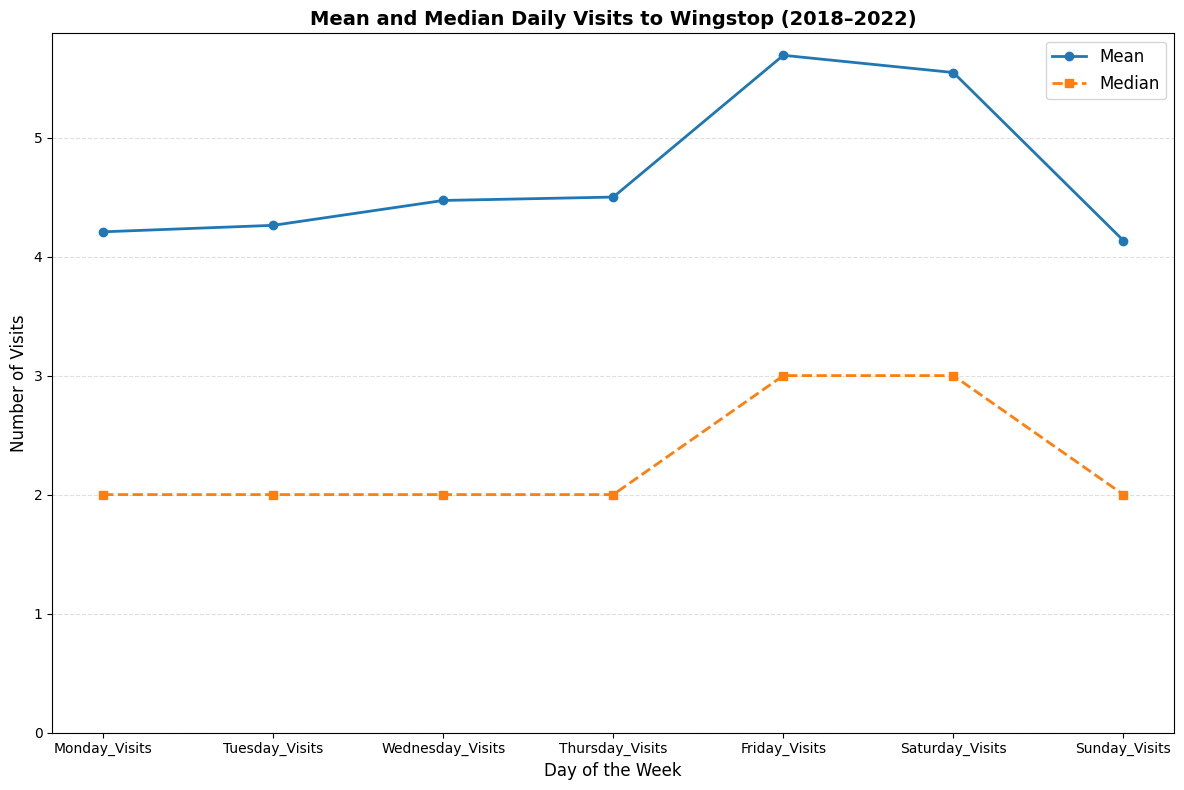

In [ ]:
days_mean = df[days].mean()
days_median = df[days].median()

plt.figure(figsize=(12, 8))
plt.plot(days, days_mean, label="Mean", marker='o', linewidth=2)
plt.plot(days, days_median, label="Median", marker='s', linewidth=2, linestyle='--')
plt.legend(fontsize=12)
plt.title("Mean and Median Daily Visits to Wingstop (2018–2022)", fontsize=14, fontweight='bold')
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)
plt.ylim(bottom=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

This line graph visualization corroborates with what was previously deduced from the mean and the median.
Conclusion: The dat of the week has a meaningful and consistent relationship with visit volume. Customers visit Wingstop a lot more on Fridays and Saturdays than on weekdays. This pattern justifies including day_of_week as a feature in our predictive model.

# 4.2 Is the Distribution of Average Visits Symmetric Across Cities?
Motivation: Our dataset covers multiple Maryland cities, each with at least one Wingstop location. Before modeling, we need to understand whether visit volume is distributed evenly across cities or concentrated in a few high-traffic locations. This matters for modeling because a heavily skewed distribution can affect how much influence individual locations have on model training.

We begin by computing the average weekly visit count per city, then examine its spread using variance, standard deviation, and a skewness test.

In [ ]:
city_avg_df = df.groupby('city')['raw_visit_counts'].mean().reset_index()
city_avg_df = city_avg_df.rename(columns={'raw_visit_counts': 'avg_raw_visit_counts'})
city_avg_df.head()

,city,avg_raw_visit_counts
0,Aspen Hill,50.864542
1,Baltimore,9.451128
2,Dundalk,14.612000
3,Ellicott City,173.364000
4,Frederick,22.054902


We first find the mean for each city.

In [ ]:
variance_visits = city_avg_df['avg_raw_visit_counts'].var()
std_dev_visits = city_avg_df['avg_raw_visit_counts'].std()
mean_visits = city_avg_df['avg_raw_visit_counts'].mean()

print(f"Variance of Average Raw Visit Counts: {variance_visits:.2f}")
print(f"Standard Deviation of Average Raw Visit Counts: {std_dev_visits:.2f}")
print(f"Mean of Average Raw Visit Counts: {mean_visits:.2f}")

Variance of Average Raw Visit Counts: 2341.75
Standard Deviation of Average Raw Visit Counts: 48.39
Mean of Average Raw Visit Counts: 33.36


The high standard deviation relative to the mean is a first signal that visit counts are not tightly clustered. To visualize the full distribution, we use a histogram.

To visualize this distribution, we can use a histogram.

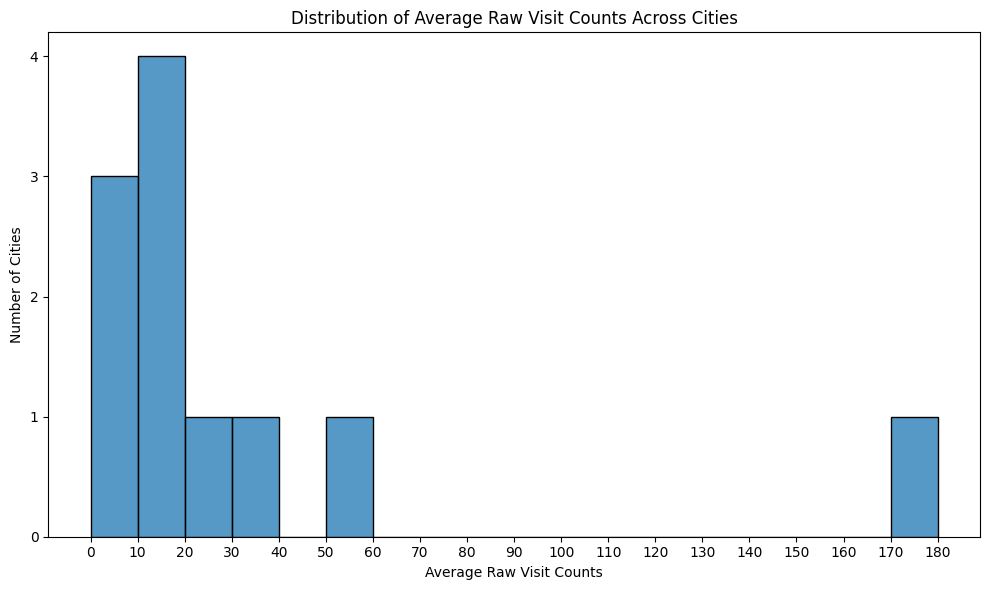

In [ ]:
plt.figure(figsize=(10, 6))
min_val = city_avg_df['avg_raw_visit_counts'].min()
max_val = city_avg_df['avg_raw_visit_counts'].max()

bins = np.arange(0, max_val + 10, 10)
sns.histplot(city_avg_df['avg_raw_visit_counts'], bins=bins)

plt.title('Distribution of Average Raw Visit Counts Across Cities')
plt.xlabel('Average Raw Visit Counts')
plt.ylabel('Number of Cities')

plt.xticks(bins)

plt.yticks([0 ,1, 2, 3, 4])
plt.tight_layout()
plt.show()

Looking at the standard deviation of this data as well as the histogram we can clearly see that the data has a large variance and is positively skewed. Also from looking at the data we can see that there is one restaurant in the data set with a significantly higher than average amount of weekly visitors.

In [ ]:
skewness = city_avg_df['avg_raw_visit_counts'].skew()
print(f"Skewness of Average Raw Visit Counts: {skewness:.2f}")

Skewness of Average Raw Visit Counts: 2.88


Conclusion: The distribution is positively skewed — most cities have modest average visit counts, but one location stands out with a significantly higher volume than the rest. This right-skewed distribution tells us that city is not a uniform predictor of visits; some locations are meaningfully busier than others, making city a relevant feature for our model.

# 4.3 Hypothesis Test: Did COVID-19 Significantly Impact In-Person Visits?


Now we will be looking into the effects of COVID on the daily visits of Wingstop. For convenience, we will be seperating our dates by pre and post COVID  using January 2020 (Time COVID was announced) as our cutoff

Motivation: Our dataset spans 2018–2022, a period that includes the onset of the COVID-19 pandemic in early 2020. It is reasonable to expect that in-person restaurant visits dropped during this period, but we want to test this statistically rather than assume it. Quantifying the COVID effect also justifies including a covid_period binary variable as a feature in our model.
We split the data into two independent groups using January 2020 — when the WHO announced COVID-19 — as the dividing cutoff:

Pre-COVID: 2018–2019
Post-COVID: January 2020–December 2022

Hypotheses:

Null hypothesis (H₀): COVID-19 had no effect on average weekly in-person visits at Maryland Wingstop locations.
Alternative hypothesis (H₁): COVID-19 had a statistically significant effect on average weekly in-person visits.

We use a two-sample t-test, which is appropriate here because we are comparing the means of two independent groups (pre- and post-COVID weeks) and do not assume equal variances between them.

In [ ]:
# Cutline: January 2020 = when COVID-19 was announced by WHO
df['date_range_start'] = pd.to_datetime(df['date_range_start'], utc=True)

cutline = pd.Timestamp('2020-01-01', tz='UTC')

df_pre  = df[df['date_range_start'] < cutline]
df_post = df[df['date_range_start'] >= cutline]

total_visits_2018 = df[df['Year'] == 2018]['raw_visit_counts'].sum()
total_visits_2019 = df[df['Year'] == 2019]['raw_visit_counts'].sum()
total_visits_pre  = df_pre['raw_visit_counts'].sum()
total_visits_post = df_post['raw_visit_counts'].sum()

print(f"Total visits in 2018:                 {total_visits_2018}")
print(f"Total visits in 2019:                 {total_visits_2019}")
print(f"Total visits pre-COVID  (< Jan 2020): {total_visits_pre}")
print(f"Total visits post-COVID (>= Jan 2020): {total_visits_post}")

Total visits in 2018:                 19470.0
Total visits in 2019:                 24869.0
Total visits pre-COVID  (< Jan 2020): 44339.0
Total visits post-COVID (>= Jan 2020): 49112.0


We will be using a T test as we will be comparing the means of the two group that are indpendent, as they won't be influencing one another and we are interested in average level of visits will shift meaningfully between those periods. For this section we will be working on these hypothesis

Null Hypothesis: COVID had no impact on in-person visits at Wingstop Maryland locations.

Alternate Hypothesis: COVID had a statistically significatn impact on in-person visits at Wingstop Maryland locations.

In [ ]:
# Pre-COVID:  2018 – 2019 (before COVID announcement)
# Post-COVID: Jan 2020 – Dec 2022 (COVID announcement and onward)
visits_pre  = df_pre['raw_visit_counts'].dropna()
visits_post = df_post['raw_visit_counts'].dropna()

t_stat, p_value = stats.ttest_ind(visits_pre, visits_post, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print(f"With a p-value of {p_value:.10f}, which is less than our alpha of {alpha}, we reject the null hypothesis.")
    print("There is a statistically significant difference in raw visit counts before and after the COVID cutline (January 2020).")
else:
    print(f"With a p-value of {p_value:.10f}, which is greater than our alpha of {alpha}, we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in raw visit counts before and after the COVID cutline (January 2020).")

print(f"\nMean raw_visit_counts pre-COVID  (2018 – 2019):         {visits_pre.mean():.2f}")
print(f"Mean raw_visit_counts post-COVID (Jan 2020 – Dec 2022): {visits_post.mean():.2f}")

T-statistic: 4.842
P-value: 0.000
With a p-value of 0.0000013828, which is less than our alpha of 0.05, we reject the null hypothesis.
There is a statistically significant difference in raw visit counts before and after the COVID cutline (January 2020).

Mean raw_visit_counts pre-COVID  (2018 – 2019):         38.52
Mean raw_visit_counts post-COVID (Jan 2020 – Dec 2022): 28.96


The p-value is far below our significance threshold of a = 0.05, so we reject the null hypothesis. The box plot below visualizes the difference in distribution between the two periods.

Now moving on to the visualization part. We will be using a box plot to compare if two distributions are significantly different.

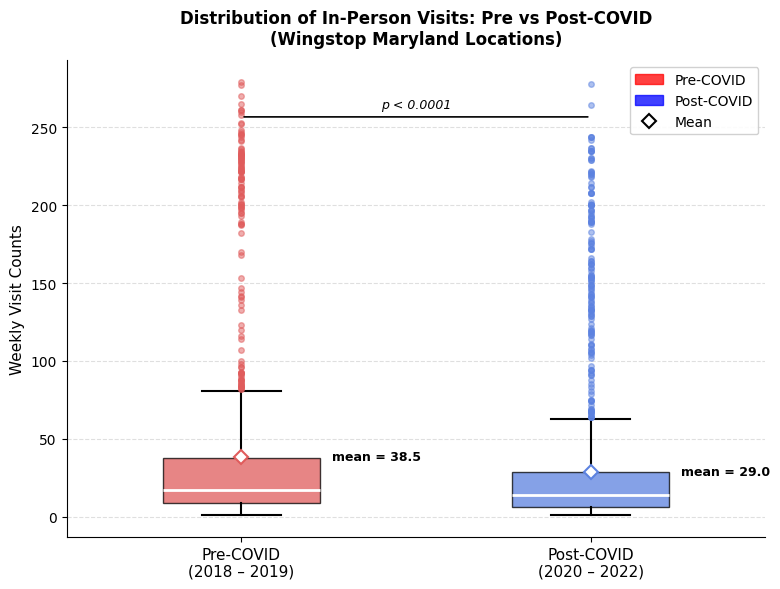

In [ ]:
# Build the two groups for t-test
visits_pre  = df_pre['raw_visit_counts'].dropna()
visits_post = df_post['raw_visit_counts'].dropna()

fig, ax = plt.subplots(figsize = (8, 6))

box_p = ax.boxplot(
    [visits_pre, visits_post],
    patch_artist = True,
    widths = 0.45,
    medianprops = dict(color = 'white', linewidth = 2),
    whiskerprops = dict(linewidth = 1.5),
    capprops = dict(linewidth = 1.5),
    flierprops = dict(marker = 'o', markersize = 4, linestyle = 'none', alpha = 0.5)
)

colors = ['#e05c5c', '#5c82e0']
for patch, color in zip(box_p['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(box_p['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# Means
for i, (group, color) in enumerate(zip([visits_pre, visits_post], colors), 1):
    mean_val = group.mean()
    ax.plot(i, mean_val, marker = 'D', color='white', markersize = 7,
            markeredgecolor = color, markeredgewidth = 1.5, zorder = 5, label = 'Mean' if i == 1 else '')
    ax.text(i + 0.26, mean_val, f'mean = {mean_val:.1f}',
            va = 'center', fontsize = 9, color = 'black', fontweight = 'bold')

# p-value
y_max = max(visits_pre.max(), visits_post.max())
ax.annotate('', xy = (2, y_max * 0.92), xytext = (1, y_max * 0.92),
            arrowprops = dict(arrowstyle = '-', color = 'black', lw = 1.2))
ax.text(1.5, y_max * 0.94, 'p < 0.0001', ha = 'center', fontsize = 9,
        color = 'black', fontstyle = 'italic')

# Styling
ax.set_xticks([1, 2])
ax.set_xticklabels(['Pre-COVID\n(2018 – 2019)', 'Post-COVID\n(2020 – 2022)'], fontsize = 11)
ax.set_ylabel('Weekly Visit Counts', fontsize = 11)
ax.set_title('Distribution of In-Person Visits: Pre vs Post-COVID\n(Wingstop Maryland Locations)',
             fontsize = 12, fontweight = 'bold', pad = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.4)
ax.spines[['top', 'right']].set_visible(False)

pre_patch  = mpatches.Patch(color = 'red', alpha = 0.75, label = 'Pre-COVID')
post_patch = mpatches.Patch(color = 'blue', alpha =0.75, label = 'Post-COVID')
mean_marker = plt.Line2D([0], [0], marker = 'D', color = 'w', markeredgecolor = 'black',
                          markeredgewidth = 1.5, markersize = 7, label = 'Mean')
ax.legend(handles = [pre_patch, post_patch, mean_marker], fontsize = 10, framealpha = 0.9)

plt.tight_layout()
plt.show()


Conclusion: Mean weekly visits dropped from approximately 38.5 pre-COVID to 29 during the COVID period: a decline of roughly 25%. The post-COVID distribution is also tighter, suggesting not just fewer visits on average, but less week-to-week variability, likely reflecting suppressed but stable demand during lockdown and recovery periods. This statistically significant difference validates including the period of covid as a binary feature in our model.

# Summary of EDA Findings
This is a brief summary of our findings from EDA:

**Question**: Does day of week affect visits?
**What method used**: Descriptive statistics (mean, median)
**Key Finding**: Friday/Saturday see ~50% more visits than Monday–Thursday

**Question**: Are visit counts symmetric across cities?
**What method used**: Variance, skewness, histogram
**Key Finding**: Distribution is positively skewed; one city is a significant outlier


**Question**: Did COVID impact visit volume?
**What method used**: two-sample t-test
**Key Finding**: Yes, mean visits dropped ~25% post-COVID (p < 0.0001)


Each of these findings: day of week, city-level variation, and the COVID disruption, directly shaped the feature set of the Random Forest model described in the next section.


# Primary Analysis

In [ ]:
# Create a dataset where each row represents a city-day combination
data_for_model = []

for idx, row in df.iterrows():
    city = row['city']
    year = row['Year']
    # Create binary COVID variable: 1 if year >= 2020 (COVID period), 0 if before 2020 (pre-COVID)
    covid_binary = 1 if year >= 2020 else 0

    for day_idx, day_name in enumerate(days):
        visits = row[day_name]
        data_for_model.append({
            'city': city,
            'day_of_week': day_name.replace('_Visits', ''),
            'visits': visits,
            'covid_period': covid_binary  # 1 = COVID period (2020+), 0 = Pre-COVID
        })

# Convert to DataFrame
model_df = pd.DataFrame(data_for_model)

print("Model Dataset Shape:", model_df.shape)
print(model_df.head(10))
print("\nDataset Statistics:")
print(model_df['visits'].describe())
print("\nCOVID Period Distribution:")
print(f"Pre-COVID (0): {(model_df['covid_period'] == 0).sum()} records")
print(f"COVID Period (1): {(model_df['covid_period'] == 1).sum()} records")

Model Dataset Shape: (19929, 4)
                 city day_of_week  visits  covid_period
0  Montgomery Village      Monday     1.0             0
1  Montgomery Village     Tuesday     2.0             0
2  Montgomery Village   Wednesday     0.0             0
3  Montgomery Village    Thursday     1.0             0
4  Montgomery Village      Friday     0.0             0
5  Montgomery Village    Saturday     1.0             0
6  Montgomery Village      Sunday     0.0             0
7         Hyattsville      Monday     0.0             0
8         Hyattsville     Tuesday     0.0             0
9         Hyattsville   Wednesday     0.0             0

Dataset Statistics:
count    19918.000000
mean         4.688372
std          7.541276
min          0.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         62.000000
Name: visits, dtype: float64

COVID Period Distribution:
Pre-COVID (0): 8057 records
COVID Period (1): 11872 records


In [ ]:
## Encode categorical features (city and day_of_week)
# Create label encoders for categorical variables
city_encoder = LabelEncoder()
day_encoder = LabelEncoder()

model_df['city_encoded'] = city_encoder.fit_transform(model_df['city'])
model_df['day_encoded'] = day_encoder.fit_transform(model_df['day_of_week'])

# Features and target
X = model_df[['city_encoded', 'day_encoded', 'covid_period']]  # Include COVID period as feature
y = model_df['visits']
y.fillna(0, inplace=True)  # Fill any missing visit counts with 0

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nDay of Week Encoding:")
for i, day in enumerate(day_encoder.classes_):
    print(f"  {i}: {day}")
print("\nCOVID Period Encoding:")
print("  0: Pre-COVID (2018-2019)")
print("  1: COVID Period (2020-2022)")
print("\nSample of encoded features:")
print(model_df[['city', 'day_of_week', 'city_encoded', 'day_encoded', 'covid_period', 'visits']].head())

Training set size: (15943, 3)
Testing set size: (3986, 3)

Day of Week Encoding:
  0: Friday
  1: Monday
  2: Saturday
  3: Sunday
  4: Thursday
  5: Tuesday
  6: Wednesday

COVID Period Encoding:
  0: Pre-COVID (2018-2019)
  1: COVID Period (2020-2022)

Sample of encoded features:
                 city day_of_week  city_encoded  day_encoded  covid_period  \
0  Montgomery Village      Monday             8            1             0   
1  Montgomery Village     Tuesday             8            5             0   
2  Montgomery Village   Wednesday             8            6             0   
3  Montgomery Village    Thursday             8            4             0   
4  Montgomery Village      Friday             8            0             0   

   visits  
0     1.0  
1     2.0  
2     0.0  
3     1.0  
4     0.0  


In [ ]:
## Train Random Forest Model with K-Fold Cross-Validation
# Setup K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)

# Perform K-Fold Cross-Validation with multiple metrics

print("K-FOLD CROSS-VALIDATION (5 Folds)")


cv_r2_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='r2')
cv_rmse_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='neg_mean_squared_error')
cv_mae_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='neg_mean_absolute_error')
y_std = np.std(y)



# Convert negative scores back to positive for RMSE and MAE
cv_rmse_scores = np.sqrt(-cv_rmse_scores)
cv_mae_scores = -cv_mae_scores
cv_std_accuracy_scores = 1 - (cv_rmse_scores / y_std)

print("\nR² Scores per fold:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean R² Score: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std():.4f})")

print("\nRMSE per fold:")
for i, score in enumerate(cv_rmse_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean RMSE: {cv_rmse_scores.mean():.4f} (+/- {cv_rmse_scores.std():.4f})")

print("\nMAE per fold:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean MAE: {cv_mae_scores.mean():.4f} (+/- {cv_mae_scores.std():.4f})")

print("\nStandard-Deviation-Based Accuracy per fold:")
for i, score in enumerate(cv_std_accuracy_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean Std-Based Accuracy: {cv_std_accuracy_scores.mean():.4f} (+/- {cv_std_accuracy_scores.std():.4f})")

# Train final model on entire dataset for feature importance
rf_model.fit(X, y)



K-FOLD CROSS-VALIDATION (5 Folds)

R² Scores per fold:
  Fold 1: 0.7628
  Fold 2: 0.7944
  Fold 3: 0.7842
  Fold 4: 0.7745
  Fold 5: 0.7803
  Mean R² Score: 0.7792 (+/- 0.0105)

RMSE per fold:
  Fold 1: 3.6464
  Fold 2: 3.3868
  Fold 3: 3.6496
  Fold 4: 3.5187
  Fold 5: 3.4994
  Mean RMSE: 3.5402 (+/- 0.0989)

MAE per fold:
  Fold 1: 2.1041
  Fold 2: 2.0666
  Fold 3: 2.1160
  Fold 4: 2.0420
  Fold 5: 2.0421
  Mean MAE: 2.0742 (+/- 0.0309)

Standard-Deviation-Based Accuracy per fold:
  Fold 1: 0.5164
  Fold 2: 0.5508
  Fold 3: 0.5160
  Fold 4: 0.5333
  Fold 5: 0.5359
  Mean Std-Based Accuracy: 0.5305 (+/- 0.0131)


RandomForestRegressor(max_depth=10, random_state=42)

In [ ]:
## Feature Importance Analysis
print("Feature Importance Scores:")
print(f"City importance: {rf_model.feature_importances_[0]:.4f}")
print(f"Day of Week importance: {rf_model.feature_importances_[1]:.4f}")
print(f"COVID Period importance: {rf_model.feature_importances_[2]:.4f}")

Feature Importance Scores:
City importance: 0.9453
Day of Week importance: 0.0321
COVID Period importance: 0.0226


In [ ]:
print("\n 5 random selected samples with predictions:")
random_cities = model_df["city"].drop_duplicates().sample(n=5, random_state=42)
for city in random_cities:
    # Filter the dataset to only that city
    city_data = model_df[model_df["city"] == city]

    # Pick one random row/sample from that city
    random_sample = city_data.sample(n=1, random_state=42).iloc[0]

    # Pull values from the random sample
    day = random_sample["day_of_week"]
    covid_period = random_sample["covid_period"]
    actual_visits = random_sample["visits"]

    # Encode categorical values the same way as training data
    city_encoded = city_encoder.transform([city])[0]
    day_encoded = day_encoder.transform([day])[0]

    # Create input for prediction
    X_random = np.array([[city_encoded, day_encoded, covid_period]])

    # Make prediction
    rf_prediction = rf_model.predict(X_random)[0]

    # Print results
    print(f"City: {city}")
    print(f"Day: {day}")
    if covid_period == 0:
        covid_period_str = "Pre-COVID (2018-2019)"
    else:
        covid_period_str = "COVID Period (2020-2022)"
    print(f"COVID Period: {covid_period_str}")
    print(f"Actual Visits: {actual_visits:.1f}")
    print(f"Predicted Visits: {rf_prediction:.1f}")
    print("-" * 40)


 5 random selected samples with predictions:
City: Rockville
Day: Wednesday
COVID Period: Pre-COVID (2018-2019)
Actual Visits: 4.0
Predicted Visits: 2.5
----------------------------------------
City: Montgomery Village
Day: Wednesday
COVID Period: Pre-COVID (2018-2019)
Actual Visits: 0.0
Predicted Visits: 0.9
----------------------------------------
City: Frederick
Day: Wednesday
COVID Period: COVID Period (2020-2022)
Actual Visits: 3.0
Predicted Visits: 3.1
----------------------------------------
City: Dundalk
Day: Monday
COVID Period: COVID Period (2020-2022)
Actual Visits: 0.0
Predicted Visits: 1.9
----------------------------------------
City: Garrison
Day: Wednesday
COVID Period: Pre-COVID (2018-2019)
Actual Visits: 10.0
Predicted Visits: 6.2
----------------------------------------


The machine learning model that we chose to use was a regression model. The model looked at all 3 factors we looked at for amount of daily visitors in the exploratory data analysis phase(day of the week, city, and whether the data was from before or after covid hit). We chose to use a random forest because it does a good job preventing overfitting while also keeping good accuracy. Based on the results of the testing, the model was somewhat accurate, but not great with the average actual result being around .5 standard deviations away from the predicted. This is most likely due to factors not being tracked such as the weather for that day and any inaccuracies in the data.

# Visualization

Figure 1 



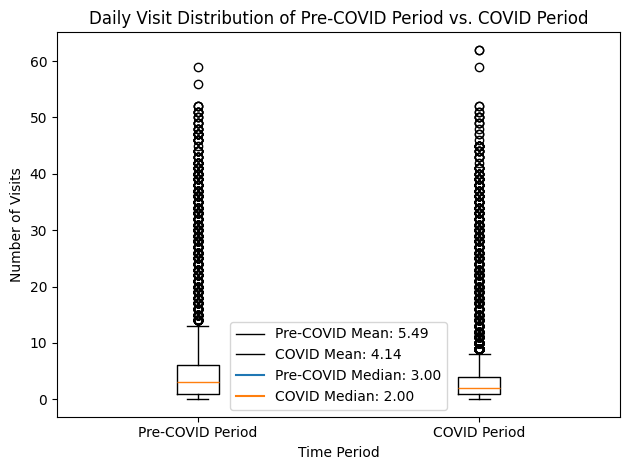

In [ ]:
print("Figure 1 \n")

pre_covid = model_df[model_df['covid_period'] == 0]['visits']
covid = model_df[model_df['covid_period'] == 1]['visits']

box_data = [pre_covid, covid]
labels = ['Pre-COVID Period', 'COVID Period']

plt.boxplot(box_data, labels=labels)
plt.xlabel('Time Period')
plt.ylabel('Number of Visits')
plt.title('Daily Visit Distribution of Pre-COVID Period vs. COVID Period')

legend_labels = [f'Pre-COVID Mean: {pre_covid.mean():.2f}', f'COVID Mean: {covid.mean():.2f}',
                 f'Pre-COVID Median: {pre_covid.median():.2f}', f'COVID Median: {covid.median():.2f}']

helper = [plt.plot([], [])[0] for _ in range(4)]
plt.legend(legend_labels)

plt.tight_layout()
plt.show()

Figure 1 shows a box plot comparing the daily visitor counts across all cities during the pre-COVID period (2018-2019) and the COVID period (2020-2022). The mean daily visits decreased from 5.49 during the pre-COVID period to 4.14 during the COVID period, showing a slight change, while the median dropped from 3.00 to 2.00 visits. Both box plots show positive skew, indicating outliers where visits often exceeded the upper quartile reaching to more than 60 visits a day. This data suggests that the COVID-19 pandemic had a negative impact on daily visitor counts across these cities, reducing both average and typical daily foot traffic.

Figure 2 



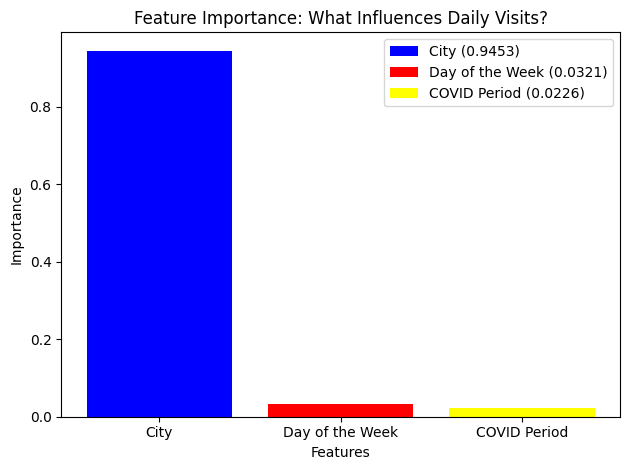

In [ ]:
print("Figure 2 \n")

features = ['City', 'Day of the Week', 'COVID Period']
importances = [0.9453, 0.0321, 0.0226]

bars = plt.bar(features, importances, color = ['blue', 'red', 'yellow'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance: What Influences Daily Visits?')

legend_labels = [f'{feature} ({importance:.4f})' for feature, importance in zip(features, importances)]
plt.legend(bars, legend_labels)

plt.tight_layout()
plt.show()

Figure 2 shows a bar chart displaying the factors that most strongly predict the daily visitor counts based on the random forest regression model. City location is the most important feature with an importance score of 0.9453, meaning the city alone determines 94.5% of the model's ability to predict daily visits. Day of the week and COVID period have significantly less of an influence when compared to city. This indicates that the location determines visitation patterns far more than when the visit occurred or whether it was during the pandemic.

# Summary

This project set out to answer three questions about in-person customer traffic at Maryland Wingstop locations between 2018 and 2022. Here is what the data told us, and what it means in practice.

Day of the week matters, but not hugely. Fridays and Saturdays consistently attract roughly 50% more visits than weekdays, a pattern that held across both the mean and median, meaning it is not a quirk of a few busy outlier weeks. For a franchise manager, this confirms what intuition might already suggest, weekend staffing should be meaningfully heavier than midweek staffing. What is less obvious is how flat Monday through Thursday actually is, suggesting that mid-week promotions could be worthwhile.

City location dominates everything else. The Random Forest model assigned city an importance score of 0.945, meaning roughly 94.5% of the model's predictive power came from knowing which city a location was in. Day of week and COVID period, despite both being statistically meaningful on their own, were almost irrelevant once city was in the model. This is a striking finding. It suggests that local factors, neighborhood demographics, nearby competition, foot traffic anchors like shopping centers or offices, matter far more than timing or even a global pandemic for predicting how busy a given location will be. A regional operator trying to forecast demand should therefore invest heavily in understanding location-specific baselines before worrying about seasonality or event calendars.

COVID had a real and statistically significant impact. Mean weekly visits fell roughly 25% after January 2020 (from around 38.5 to 29 visits per week, or from a mean of 5.49 to 4.14 at the daily). The t-test confirmed this was not noise, as p was lesser than 0.0001. Interestingly, the post-COVID distribution was also tighter, less week-to-week variability, suggesting that during the pandemic, demand was suppressed but relatively stable, rather than wildly unpredictable.

The city distribution is skewed, not uniform. One Maryland location significantly outperformed all others, while most clustered at modest visit counts. Any aggregate analysis, including ours, can be pulled by that outlier. Planners should be careful not to use chain-wide Maryland averages as a target for individual locations, the range of "normal" is wide.

We have tried to build the case from the ground up, explaining each analysis and tying every statistical test to a plan-language conclusion. A reader who does not have any prior understanding of statistics or models and tests would finish the project understanding that COVID meaningfully reduced in-person visits and that Fridays and Saturdays are the busiest days at Wingstop. They would also understand that the location of the establishment is the single biggest driver of how busy any given store will be.
Similarly, for someone who is already familiar with the effects of COVID on the economy would walk in expecting the pandemic to be the biggest driving factor influencing the visits to an establishment. But once they go through the project, they will understand that COVID and the day of the week do not influence this parameter as much as the location of the establishment. They will also be able to notice that the post-COVID demand was not just lower but less variable.